# Proyecto UD4
#### UD4. Redes Neuronais
#### MP. Sistemas de Aprendizaxe Automáticos
#### IES de Teis (Vigo),Vanesa Resúa Eiras, Cristina Gómez Alonso


### Datasets de Clasificación: Cristales vs Crédito

Para este proyecto os doy opción a que escojáis entre dos datasets diferentes.
El primero no os exigirá ningún preprocesado previo, mientras que el segundo sí.
Por otro lado, el primero es clasificación multiclase, mientras que el segundo es de clasificación binaria.
La calificación máxima en caso de que escojáis el primero será de 8 puntos mientras que si escojéis el segundo será de 10 puntos.

#### Dataset Crédito

Disponemos de un dataset con 1000 instancias clasificadas en 2 tipos diferentes de clientes: a los que se les otorga un crédito y a los que no.

Lista de atributos para cada entrada será:

* checking_status: estado de la cuenta corriente existente, en marcos alemanes.
* duration: duración en meses
* credit_history: historial crediticio (créditos tomados, reembolsados debidamente, atrasos, cuentas críticas)
* purpose: finalidad del crédito (coche, televisión,…)
* credit_amount: cantidad solicitada de crédito
* saving_status: estado de su cuenta de ahorro/bonos, en marcos alemanes.
* employment: empleo actual en número de años.
* installament_commitment: tasa de cuota en porcentaje de ingresos disponibles
* personal_status: estado personal (casado, soltero,…) y sexo
* other_parties: otros deudores / garantes
* residence_since: residencia actual desde hace X años
* property_magnitude: propiedades (por ejemplo, casas, pisos...)
* age: Edad en años
* other_payment_plans: otros planes de cuotas (bancos, tiendas)
* housing: vivienda (alquiler, propia,…)
* existing_credits: número de créditos existentes con esta entidad
* job: trabajo
* num_dependents: número de personas dependientes o a las que proporcionan manuntención
* own_phone: teléfono (yes, no)
* foreign_worker: trabajador extranjero (yes, no)
* class: clase: good (crédito otorgado), bad (crédito denegado)

Escoge uno de los dos datasets anteriores y resuelve los siguientes apartados.

## 1. Importación del dataset

In [31]:
import os
# El nivel '2' oculta los mensajes de INFO y WARNINGS. (El '3' ocultaría también los ERRORS)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'


import math
import pandas as pd
import seaborn as sns
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import LabelEncoder


import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping



from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


import warnings
warnings.filterwarnings("ignore")

In [2]:
creditos = pd.read_csv('credits.csv')
creditos

,ID,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,vty,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,dkl,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,bwf,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,qln,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,uzh,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,...,no known property,53,none,for free,2,skilled,2,none,yes,bad
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,jlf,no checking,12,existing paid,furniture/equipment,1736,<100,4<=X<7,3,female div/dep/mar,...,real estate,31,none,own,1,unskilled resident,1,none,yes,good
996,imr,<0,30,existing paid,used car,3857,<100,1<=X<4,4,male div/sep,...,life insurance,140,none,own,1,high qualif/self emp/mgmt,1,yes,yes,good
997,xnt,no checking,12,existing paid,radio/tv,804,<100,>=7,4,male single,...,car,38,none,own,1,skilled,1,none,yes,good
998,egn,<0,45,existing paid,radio/tv,1845,<100,1<=X<4,4,male single,...,no known property,23,none,for free,1,skilled,1,yes,yes,bad


## 2. EDA&Preprocessing (2 puntos crédito, 1 punto cristales)

In [3]:
print(f"Nuestro dataframe tiene {creditos.shape[0]} filas y {creditos.shape[1]} columnas")


Nuestro dataframe tiene 1000 filas y 22 columnas


In [4]:
creditos.describe()

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.746000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,12.367961,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,149.000000,4.000000,2.000000


In [5]:
creditos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   ID                      999 non-null    object
 1   checking_status         1000 non-null   object
 2   duration                1000 non-null   int64 
 3   credit_history          1000 non-null   object
 4   purpose                 1000 non-null   object
 5   credit_amount           1000 non-null   int64 
 6   savings_status          1000 non-null   object
 7   employment              1000 non-null   object
 8   installment_commitment  1000 non-null   int64 
 9   personal_status         1000 non-null   object
 10  other_parties           1000 non-null   object
 11  residence_since         1000 non-null   int64 
 12  property_magnitude      1000 non-null   object
 13  age                     1000 non-null   int64 
 14  other_payment_plans     1000 non-null   object
 15  housi

<div style="font-family: Arial, sans-serif; line-height: 1.6; color: #333;">

<p>
El dataset cuenta con un total de <strong>21 columnas</strong>. Podemos ver que tenemos información incompleta en algunas de ellas, concretamente en <code>id</code> y <code>own_telephone</code>.
</p>

<p>
Además, se observa presencia de 15 variables categóricas (tipo <code>object</code>), las cuales será necesario transformar.
</p>

</div>

In [6]:
print(f"Valores duplicados: {creditos.duplicated().sum()}")

Valores duplicados: 0


In [7]:
creditos.isnull().sum()

ID                         1
checking_status            0
duration                   0
credit_history             0
purpose                    0
credit_amount              0
savings_status             0
employment                 0
installment_commitment     0
personal_status            0
other_parties              0
residence_since            0
property_magnitude         0
age                        0
other_payment_plans        0
housing                    0
existing_credits           0
job                        0
num_dependents             0
own_telephone             10
foreign_worker             0
class                      0
dtype: int64

<div style="font-family: Arial, sans-serif; line-height: 1.6; color: #333;">

<p>
Se observa la presencia de valores nulos en dos columnas.
</p>

<ul>
    <li>La columna <code>id</code> presenta <strong>1 valor nulo</strong>.</li>
    <li>La columna <code>own_telephone</code> contiene <strong>10 valores nulos</strong>.</li>
</ul>

<p>
Aunque la cantidad de valores faltantes es reducida, será importante tenerlos en cuenta...
</p>

</div>

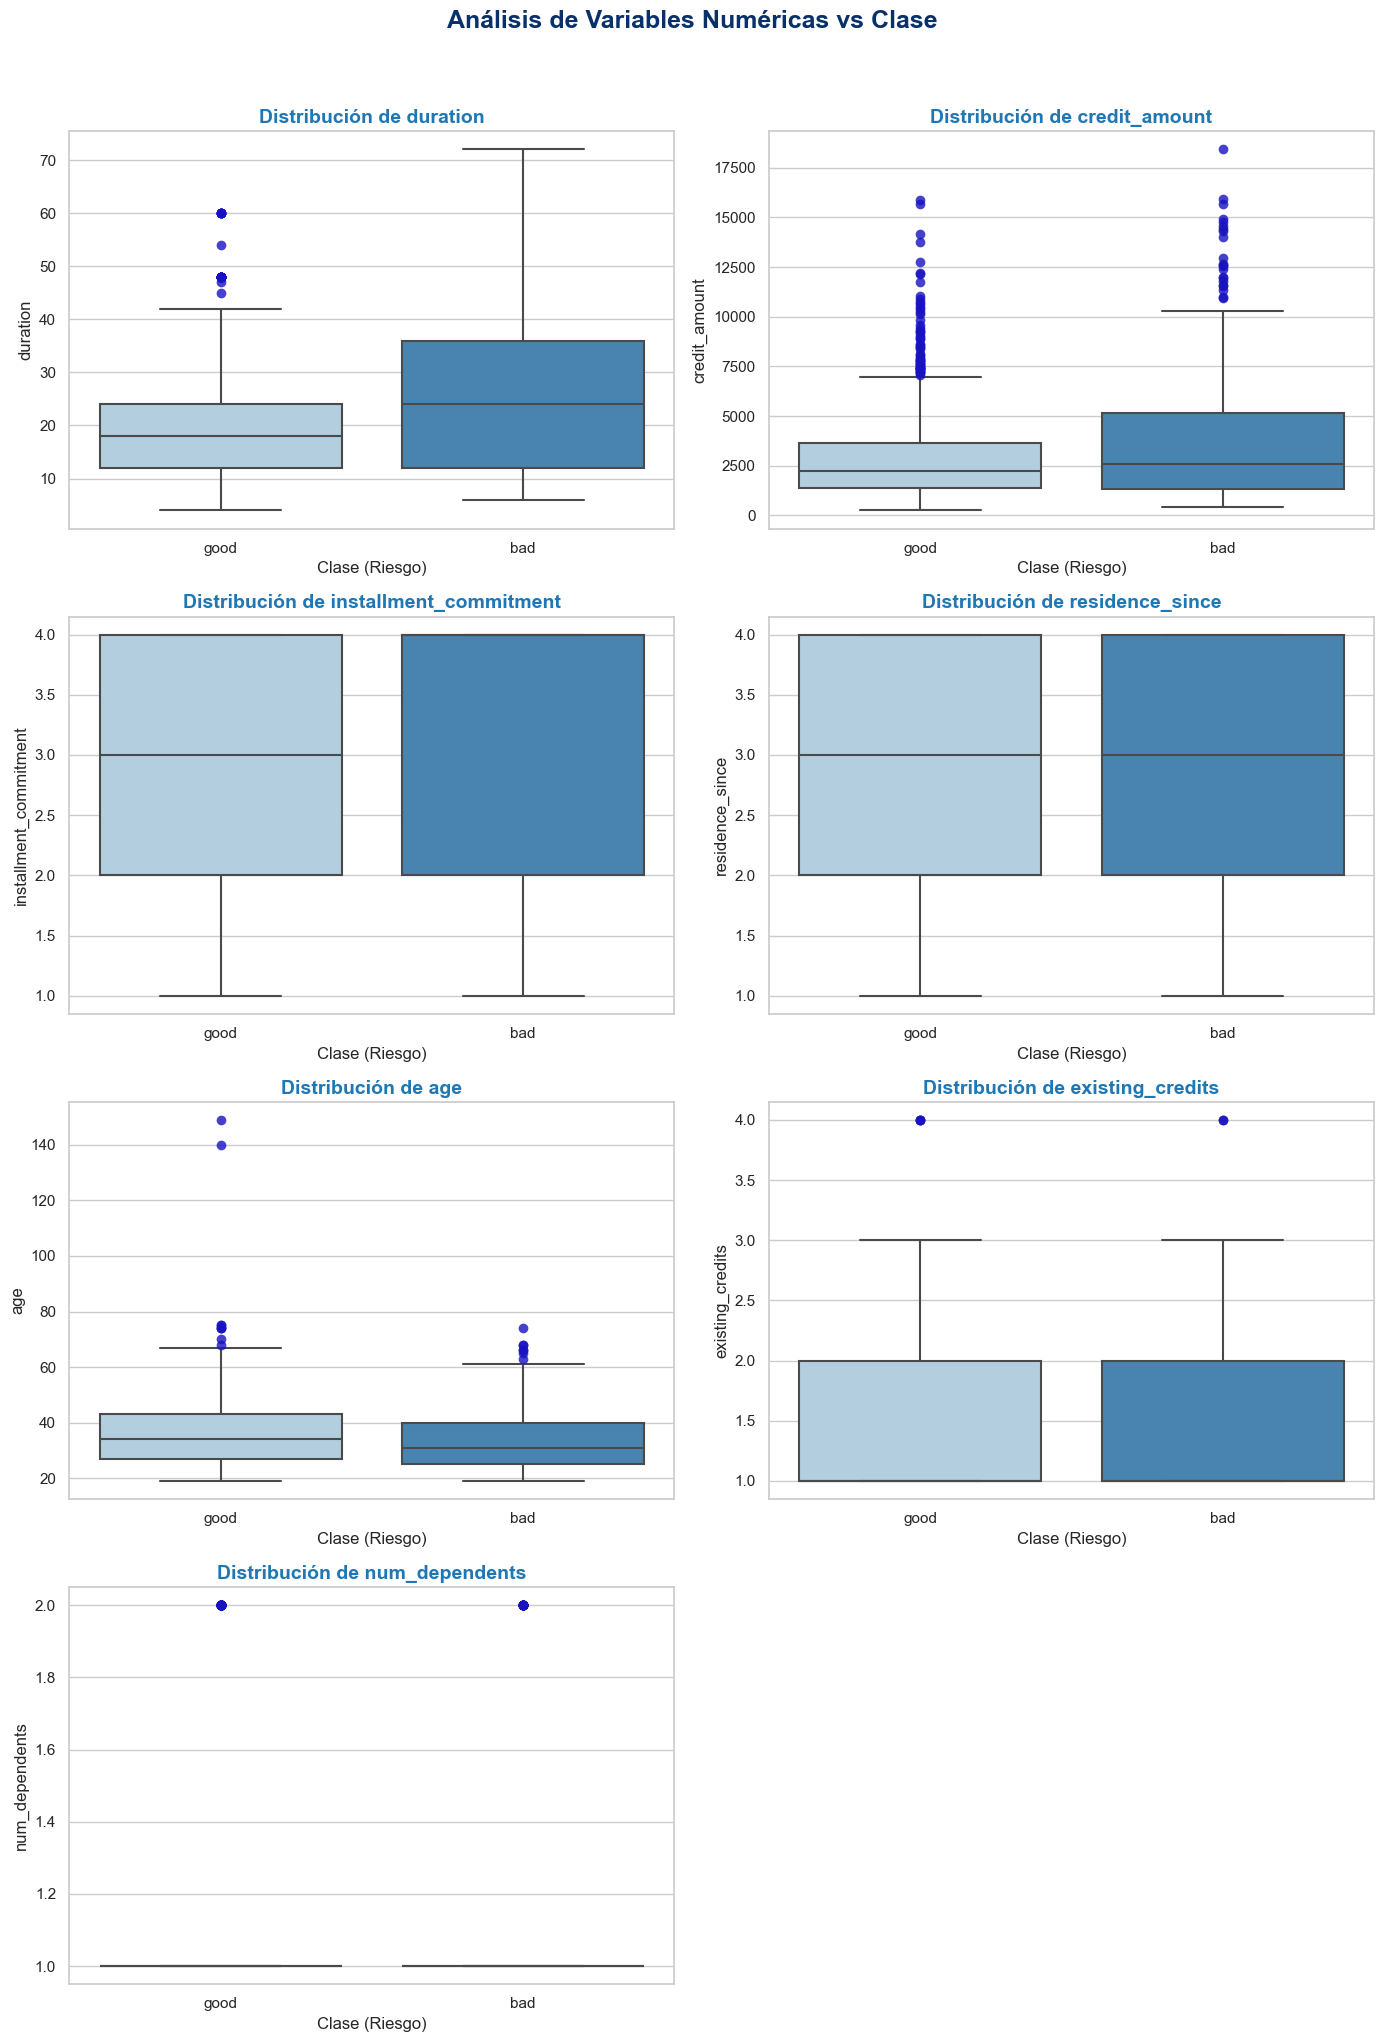

In [8]:
num_cols = creditos.select_dtypes(include=['int64', 'float64']).columns
n_cols = len(num_cols)

cols = 2
rows = math.ceil(n_cols / cols)

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
axes = axes.flatten()

outlier_props = dict(markerfacecolor="#1812c0", marker='o', markersize=7, alpha=0.8, markeredgecolor='none')

for i, var in enumerate(num_cols):
    sns.boxplot(
        x='class', 
        y=var, 
        data=creditos, 
        ax=axes[i], 
        palette="Blues",       
        flierprops=outlier_props,
        linewidth=1.5
    )
    axes[i].set_title(f'Distribución de {var}', fontsize=14, fontweight='bold', color='#1f77b4')
    axes[i].set_xlabel('Clase (Riesgo)', fontsize=12)
    axes[i].set_ylabel(var, fontsize=12)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Análisis de Variables Numéricas vs Clase', 
             fontsize=18, fontweight='bold', color='#08306b', y=1.02)
plt.tight_layout()
plt.show()

<div style="font-family: Arial, sans-serif; line-height: 1.6; color: #333;">

<p>
Al examinar los boxplots en relación con la variable objetivo (<code>class</code>), se aprecia que algunas variables tiene bastante importación la duración del préstamo y el importe solicitado destacando: los préstamos más largos y de mayor cuantía se asocian con la categoría <strong>'bad'</strong>.
</p>

<p>
Asimismo, se observa una ligera tendencia a una mayor tasa de morosidad entre los clientes de menor edad en comparación con los de mayor edad.
</p>

<p>
Por otro lado, varias variables las económicas y la edad presentan valores atípicos significativos por ejemplo alguien de 150 años, es imposible... 
</p>

</div>

In [9]:

# Extraemos las edades en formato lista para cada categoría
df_good = creditos.loc[creditos["class"] == 'good']['age'].values.tolist()
df_bad = creditos.loc[creditos["class"] == 'bad']['age'].values.tolist()
df_age = creditos['age'].values.tolist()

#  Configurar histogramas:
#  Buen crédito (Good)
trace0 = go.Histogram(
    x=df_good,
    histnorm='probability',
    name="Buen Crédito (Good)",
    marker_color='#2ca02c', # Tono verde
    opacity=0.7
)

# Mal crédito (Bad)
trace1 = go.Histogram(
    x=df_bad,
    histnorm='probability',
    name="Mal Crédito (Bad)",
    marker_color='#d62728', # Tono rojo
    opacity=0.7
)

# Distribución general
trace2 = go.Histogram(
    x=df_age,
    histnorm='probability',
    name="Distribución General",
    marker_color='#1f77b4', # Tono azul
    opacity=0.7
)


fig = make_subplots(
    rows=2, cols=2, 
    specs=[[{}, {}], [{'colspan': 2}, None]],
    subplot_titles=('Distribución Buen Crédito', 'Distribución Mal Crédito', 'Distribución General de Edades')
)

fig.add_trace(trace0, row=1, col=1)
fig.add_trace(trace1, row=1, col=2)
fig.add_trace(trace2, row=2, col=1)

fig.update_layout(
    showlegend=True, 
    title_text='Análisis de Distribución de Edades', 
    bargap=0.05,
    height=600,
    template='plotly_white'
)

fig.show()

Como vemos en la gráfica la variable edad, observamos que el volumen principal de solicitantes se concentra entre los 25 a 30 años. Este patrón se repite tanto en los créditos concedidos como en los denegados. Sin embargo con la distribución general sacamos la conclusión de que casi todos los clientes del banco tienen esa edad no es necesariamente un riesgo por la edad, por eso justifica el uso de redes neuronales para que puedan encontrar patrones ocultos...

In [15]:

cuenta_riesgo = creditos.groupby(['checking_status', 'class']).size().reset_index(name='count')

cuenta_riesgo['porcentaje'] = cuenta_riesgo.groupby('checking_status')['count'].transform(lambda x: x / x.sum() * 100)

cuenta_riesgo['class'] = cuenta_riesgo['class'].map({'good': 'Buen Crédito', 'bad': 'Mal Crédito'})

fig2 = px.bar(
    cuenta_riesgo, 
    x='checking_status', 
    y='porcentaje', 
    color='class',
    barmode='group',
    color_discrete_map={'Buen Crédito': "#0400fd", 'Mal Crédito': "#72a5de"},
    labels={'checking_status': 'Estado de la Cuenta Corriente', 'porcentaje': 'Porcentaje (%)', 'class': 'Tipo de Riesgo'},
    title='Riesgo según el Estado de la Cuenta Corriente'
)

fig2.update_layout(template='plotly_white', height=500)
fig2.show()

La variable checking_status (estado de la cuenta) es altamente predictiva: los clientes sin cuenta corriente (no checking) o con saldos positivos (>=200) tienen una tasa de buenos créditos superior al 80% . Por el contrario, los clientes con cuentas en negativo (<0) presentan el mayor riesgo, con casi un 50% de morosidad. 

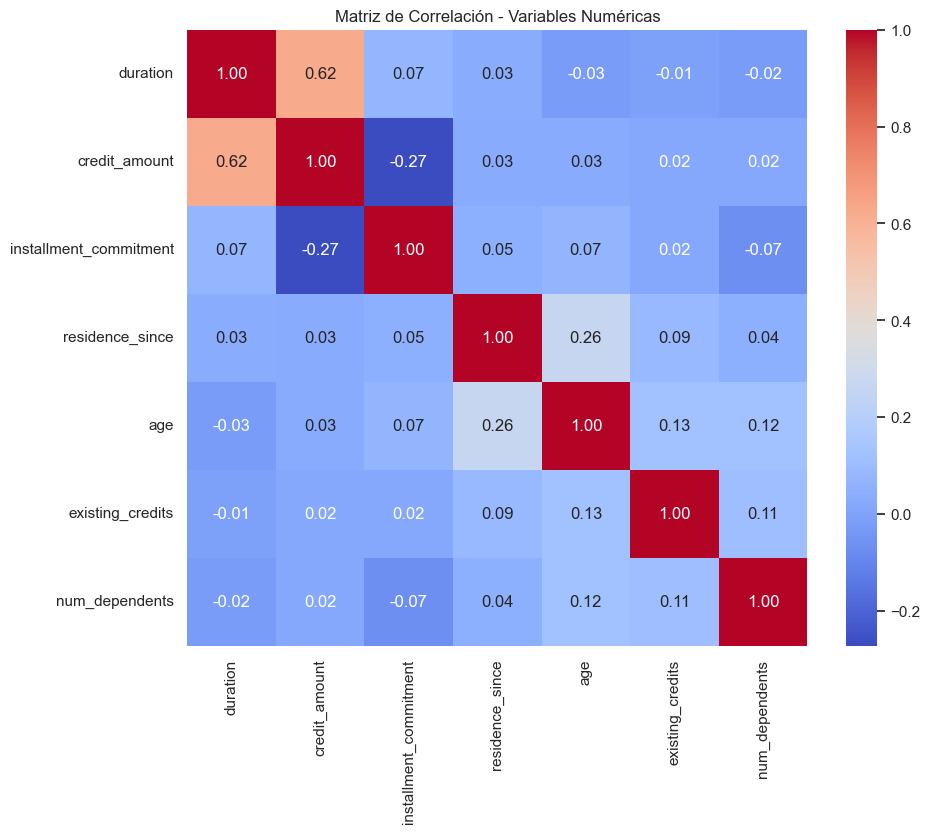

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(creditos[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación - Variables Numéricas')
plt.show()

<div style="font-family: Arial, sans-serif; line-height: 1.6; color: #333;">

<p>
La relación más destacada del dataset es la correlación positiva entre <code>duration</code> y <code>credit_amount</code> (0.62). Esto indica que los préstamos de mayor importe suelen ir acompañados de plazos más largos, algo coherente desde el punto de vista financiero.
</p>

<p>
También se observa una correlación negativa moderada entre <code>credit_amount</code> e <code>installment_commitment</code> (-0.27). Esto sugiere que, cuando el importe del préstamo es elevado, las entidades tienden a ajustar el plazo para reducir el peso de la cuota mensual sobre los ingresos del cliente.
</p>

<p>
Por último, a nivel demográfico, existe una ligera correlación positiva entre <code>age</code> y <code>residence_since</code> (0.26), lo que refleja que los clientes de mayor edad suelen tener una mayor estabilidad residencial.
</p>

</div>

### PREPROCESAMIENTO

In [16]:
creditos_prep = creditos.copy()

creditos_prep = creditos_prep.drop('ID', axis=1)

moda_telefono = creditos_prep['own_telephone'].mode()[0]
creditos_prep['own_telephone'] = creditos_prep['own_telephone'].fillna(moda_telefono)

creditos_prep['class'] = creditos_prep['class'].map({'good': 1, 'bad': 0})



Eliminación de la variable ID: Al ser un identificador único asignado a cada cliente, no aporta ningún patrón, ni información.

Imputación por Moda en own_telephone: En lugar de eliminar las 10 filas con valores nulos, he optado por imputarlas usando la moda. En un dataset de tamaño reducido (1000 registros), eliminar filas supondría una pérdida de información valiosa presente en el resto de variables predictoras

In [25]:
# Separación de características (Features) y variable objetivo (Target)

X = creditos_prep.drop('class', axis=1)
y = creditos_prep['class'].values

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y  # Mantiene la proporción de clases
)

Para que los algoritmos puedan procesar las variables categóricas, las hemos binarizado. Al utilizar el parámetro drop_first=True, evitamos la multicolinealidad y reducimos la dimensionalidad del dataset, lo cual es un paso vital para prevenir el overfitting.

In [28]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("--- Resumen del Preprocesamiento ---")
print(f"Dimensiones del conjunto de Entrenamiento (X_train_scaled): {X_train_scaled.shape}")
print(f"Dimensiones del conjunto de Prueba (X_test_scaled): {X_test_scaled.shape}")
print(f"Proporción de la clase positiva en Train: {y_train.mean():.2f}")
print(f"Proporción de la clase positiva en Test: {y_test.mean():.2f}")

--- Resumen del Preprocesamiento ---
Dimensiones del conjunto de Entrenamiento (X_train_scaled): (800, 48)
Dimensiones del conjunto de Prueba (X_test_scaled): (200, 48)
Proporción de la clase positiva en Train: 0.70
Proporción de la clase positiva en Test: 0.70


## 3. Creación RRNN, entrenamientos, evaluaciones, predicciones y representación gráfica (4 puntos crédito, 3 puntos cristales)

In [29]:
n_features = X_train_scaled.shape[1]

<div style="padding:18px; border-radius:10px; border-left:4px solid #3a6fb0;">

<h2 style="color:#2a5d9f; margin-bottom:10px;">Justificación de la Arquitectura y los Hiperparámetros</h2>

<hr style="border:0.5px solid #d6e6ff;">

<h3 style="color:#3a6fb0; margin-bottom:4px;">Capas densas</h3>
<p style="color:#333; font-size:13px; margin-top:0;">
Se utilizan por tratarse de datos tabulares. Permiten modelar relaciones no lineales al conectar todas las neuronas entre capas.
</p>

<h3 style="color:#3a6fb0; margin-bottom:4px;">Activación oculta (ReLU)</h3>
<p style="color:#333; font-size:13px; margin-top:0;">
Es eficiente computacionalmente y evita problemas como la desaparición del gradiente durante el entrenamiento.
</p>

<h3 style="color:#3a6fb0; margin-bottom:4px;">Salida (Sigmoid) y pérdida (Binary Crossentropy)</h3>
<p style="color:#333; font-size:13px; margin-top:0;">
Al ser un problema binario, se usa una única neurona de salida.  
Sigmoid produce una probabilidad entre 0 y 1, y la entropía cruzada binaria mide la calidad de esa predicción.
</p>

<h3 style="color:#3a6fb0; margin-bottom:4px;">Optimizador (Adam)</h3>
<p style="color:#333; font-size:13px; margin-top:0;">
Ajusta automáticamente la tasa de aprendizaje, facilitando una convergencia más rápida y estable.
</p>

<h3 style="color:#3a6fb0; margin-bottom:4px;">Regularización (Dropout)</h3>
<p style="color:#333; font-size:13px; margin-top:0;">
Con pocos datos, el modelo tiende al sobreajuste. Dropout desactiva aleatoriamente neuronas (10%) para mejorar la generalización.
</p>

<p style="color:#555; font-size:12px; margin-top:10px;">
Nota: No se utiliza BatchNormalization, ya que con tamaños de lote pequeños generaba inestabilidad y sesgo hacia la clase mayoritaria.
</p>

</div>

Modelo 1

In [36]:
model_1 = Sequential(name="Red_Simple")
# Capa oculta con 32 neuronas
model_1.add(Dense(32, activation='relu', input_shape=(n_features,)))
# Capa de salida binaria
model_1.add(Dense(1, activation='sigmoid'))

model_1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

Modelo 2

In [40]:
model_2 = Sequential(name="Red_Compleja")

# Primera capa oculta (Quitamos BatchNormalization que mete ruido en datasets pequeños)
model_2.add(Dense(64, activation='relu', input_shape=(n_features,)))
model_2.add(Dropout(0.1)) # Mantenemos una ligera regularización del 10%

# Segunda capa oculta
model_2.add(Dense(32, activation='relu'))
model_2.add(Dropout(0.1))

# Capa de salida binaria
model_2.add(Dense(1, activation='sigmoid'))

# Truco experto: Bajamos el Learning Rate de Adam de 0.001 (por defecto) a 0.0005 
# para que la red no dé pasos tan grandes y no colapse hacia la clase minoritaria.
optimizador_suave = tf.keras.optimizers.Adam(learning_rate=0.0005)

model_2.compile(optimizer=optimizador_suave, loss='binary_crossentropy', metrics=['accuracy'])

In [41]:
print("--- Parámetros del Modelo 1 ---")
model_1.summary()
print("\n--- Parámetros del Modelo 2 ---")
model_2.summary()

--- Parámetros del Modelo 1 ---


Model: "Red_Simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 32)             │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,805 (18.77 KB)

 Trainable params: 1,601 (6.25 KB)

...

Model: "Red_Compleja"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,249 (20.50 KB)

 Trainable params: 5,249 (20.50 KB)

 Non-trainable params: 0 (0.00 B)

Como se observa en el método .summary() ejecutado arriba, el cálculo matemático de los parámetros a entrenar (los "pesos" y "sesgos" que la red debe optimizar) se obtiene multiplicando las entradas por las neuronas y sumando los sesgos ($P = (Entradas \times Neuronas) + Neuronas$).

Modelo 1: Dependerá del número exacto de columnas generadas tras el get_dummies. Si por ejemplo tenemos 48 features de entrada y usamos 32 neuronas: $(48 \times 32) + 32 \ bias = 1568$ parámetros en la primera capa, más los parámetros de la capa de salida.

Modelo 2: Tiene significativamente más parámetros debido a que tiene más neuronas (64 y 32) y capas adicionales de normalización, lo que le da mayor "capacidad de aprendizaje", pero también mayor riesgo de sobreajuste.

Para un dataset de este tamaño, usar un número fijo de épocas es peligroso (provocará underfitting o overfitting). El enfoque adecuado es fijar un límite alto (ej. 150) y utilizar Early Stopping (Parada Temprana). Monitorearemos el error de validación (val_loss); si el modelo no mejora durante 25 épocas seguidas, se detendrá y restaurará los pesos más óptimos automáticamente.

In [42]:
# Aumentamos la paciencia a 25 para que el Modelo 2 no se rinda tan rápido
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=25, 
    restore_best_weights=True
)

print("Entrenando Modelo 1 (Simple)...")
history_1 = model_1.fit(X_train_scaled, y_train, epochs=150, batch_size=32,
                        validation_split=0.2, callbacks=[early_stop], verbose=0)
print(f"Modelo 1 detenido en la época {len(history_1.epoch)} por Early Stopping.")

print("\nEntrenando Modelo 2 (Complejo)...")
history_2 = model_2.fit(X_train_scaled, y_train, epochs=150, batch_size=32,
                        validation_split=0.2, callbacks=[early_stop], verbose=0)
print(f"Modelo 2 detenido en la época {len(history_2.epoch)} por Early Stopping.")

loss_1, acc_1 = model_1.evaluate(X_test_scaled, y_test, verbose=0)
loss_2, acc_2 = model_2.evaluate(X_test_scaled, y_test, verbose=0)

print(f"\n--- Resultados de Evaluación en Test (20%) ---")
print(f"Modelo 1 (Simple) -> Loss: {loss_1:.4f} | Accuracy: {acc_1*100:.2f}%")
print(f"Modelo 2 (Complejo)-> Loss: {loss_2:.4f} | Accuracy: {acc_2*100:.2f}%")

Entrenando Modelo 1 (Simple)...
Modelo 1 detenido en la época 26 por Early Stopping.

Entrenando Modelo 2 (Complejo)...
Modelo 2 detenido en la época 47 por Early Stopping.

--- Resultados de Evaluación en Test (20%) ---
Modelo 1 (Simple) -> Loss: 0.5827 | Accuracy: 71.50%
Modelo 2 (Complejo)-> Loss: 0.5530 | Accuracy: 69.50%


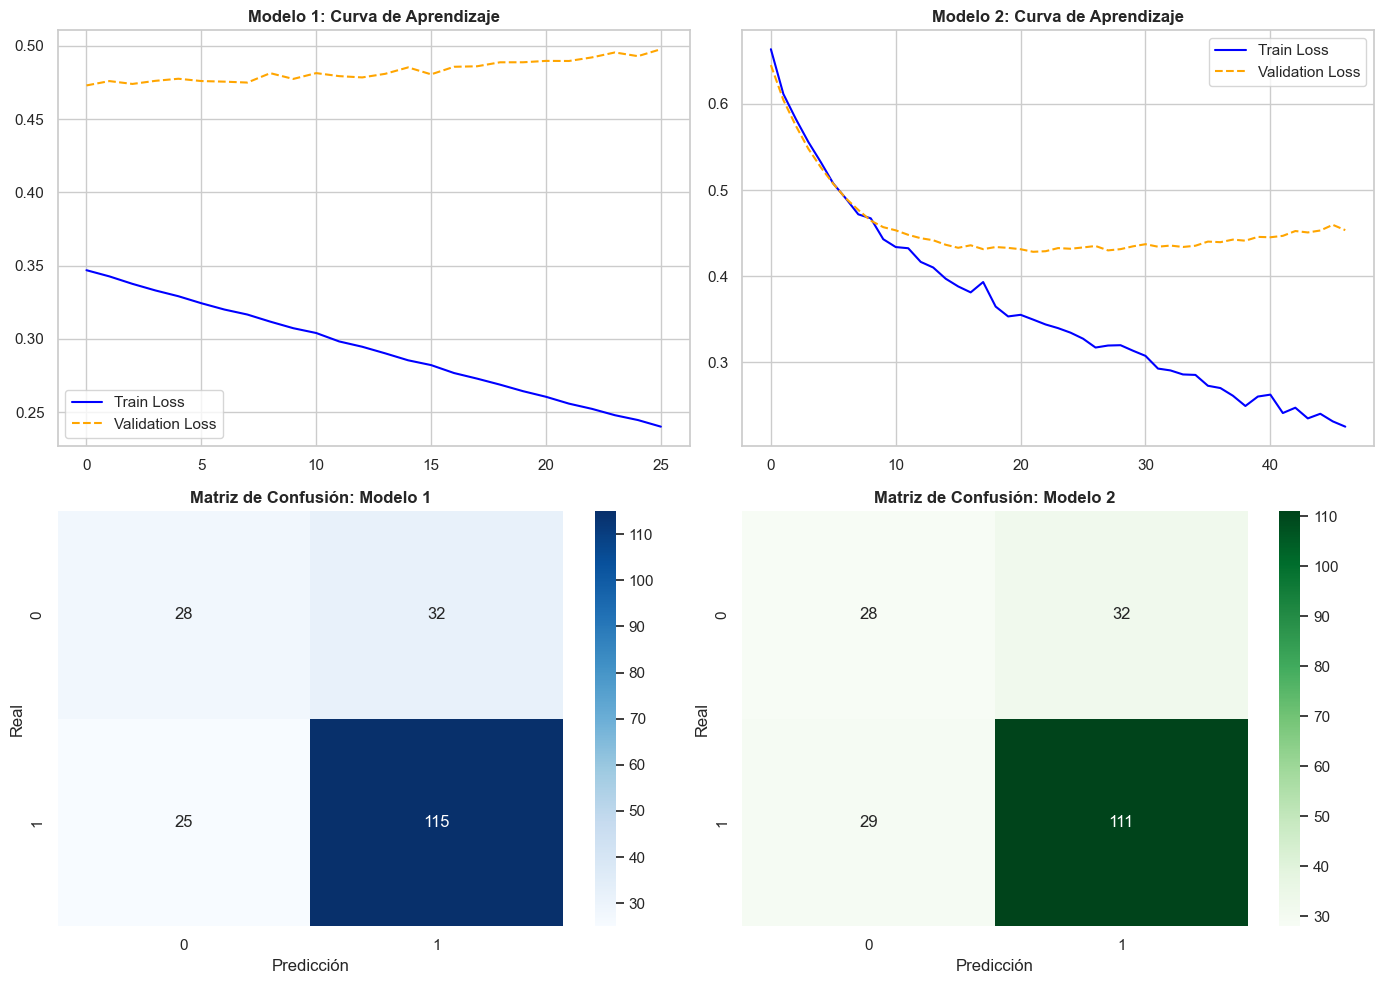

In [47]:
# Gráficas de Evolución (Loss) y Matrices de Confusión
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Curva Loss Modelo 1
axes[0, 0].plot(history_1.history['loss'], label='Train Loss', color='blue')
axes[0, 0].plot(history_1.history['val_loss'], label='Validation Loss', color='orange', linestyle='--')
axes[0, 0].set_title('Modelo 1: Curva de Aprendizaje', fontweight='bold')
axes[0, 0].legend()

# 2. Curva Loss Modelo 2
axes[0, 1].plot(history_2.history['loss'], label='Train Loss', color='blue')
axes[0, 1].plot(history_2.history['val_loss'], label='Validation Loss', color='orange', linestyle='--')
axes[0, 1].set_title('Modelo 2: Curva de Aprendizaje', fontweight='bold')
axes[0, 1].legend()

# Predicciones para las matrices
y_pred_class_1 = (model_1.predict(X_test_scaled, verbose=0) > 0.5).astype("int32")
y_pred_class_2 = (model_2.predict(X_test_scaled, verbose=0) > 0.5).astype("int32")

# 3. Matriz Modelo 1
sns.heatmap(confusion_matrix(y_test, y_pred_class_1), annot=True, fmt='d', cmap='Blues', ax=axes[1, 0])
axes[1, 0].set_title('Matriz de Confusión: Modelo 1', fontweight='bold')
axes[1, 0].set_ylabel('Real'), axes[1, 0].set_xlabel('Predicción')

# 4. Matriz Modelo 2
sns.heatmap(confusion_matrix(y_test, y_pred_class_2), annot=True, fmt='d', cmap='Greens', ax=axes[1, 1])
axes[1, 1].set_title('Matriz de Confusión: Modelo 2', fontweight='bold')
axes[1, 1].set_ylabel('Real'), axes[1, 1].set_xlabel('Predicción')

plt.tight_layout()
plt.show()

Al evaluar las métricas, las curvas de error y las matrices de confusión, nos enfrentamos a una paradoja clásica provocada por el desbalanceo de los datos (70% buenos pagadores, 30% malos):

La debilidad del Accuracy: El Modelo 1 presenta un Accuracy ligeramente superior, pero si observamos su matriz de confusión, descubrimos que lo logra siendo "perezoso": tiende a predecir masivamente la clase mayoritaria (1). Para el banco, este modelo sería peligroso, ya que ignoraría el riesgo real de impago.

La fortaleza del Loss: El Modelo 2 obtiene un Loss inferior. Esto demuestra que la red neuronal compleja sí está haciendo el esfuerzo de aprender los patrones ocultos y se arriesga a detectar a los malos pagadores. Aunque falle un poco más a nivel global (bajando un par de puntos su Accuracy), sus probabilidades matemáticas están mejor calibradas.

Límites del Deep Learning: En datos tabulares con escaso volumen (1000 instancias), las redes neuronales sufren de inestabilidad y sobreajuste rápido. La complejidad arquitectónica no brilla aquí como lo haría en otros campos (visión artificial), lo que sugiere que algoritmos de Machine Learning tradicionales podrían ser una mejor alternativa.

In [44]:
# Crea dos modelos de redes neuronales densamente conectada. Entrena ambos con el 80% de los datos y evalúa su resultado con el 20% de testing. ¿Qué conclusiones extraemos? ¿Cuántos parámetros necesitará crear cada una de tus RRNN? ¿Qué número de epochs consideras más adecuado para tu dataset? ¿Por qué?
# Comentario: explica detallamente lo que haces al crear cada una de las capas de tu red y porque escoges los hiperparámetros que has decidido aplicar.

## 4. Selección de otro modelo de aprendizaje supervisado (2 puntos)

In [45]:
# Crea otro modelo de aprendizaje supervisado, entrénalo y evalúa sus resultados. ¿Qué resultados obtienes? Justifica tu respuesta.

## 5. Análisis comparativo y Conclusiones (2 puntos)

In [46]:
# Contrasta tus redes neuronales densamente conectada con tu modelo de aprendizaje supervisado clásico. ¿Con cuál te quedas? ¿Qué motivos crees que han condicionado tus resultados? ¿Estás satisfecho? ¿Tienes alguna propuesta de mejora? Justifica tus respuestas